# Model test & validation: Gaussian Process Regression (Matern-5/2, ARD)

Full GPR is O(n^3); this model specifically subsamples training data to 2,000 points. Key tests: (1) is the subsample reproducible given a fixed seed (needed for the reproducibility requirements in the project context)? (2) what did the ARD length scales learn about which input dimension matters most?

In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
import time

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
warnings.filterwarnings("ignore")

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
def r2(y_true, y_pred):
    return float(r2_score(y_true, y_pred))

df_raw = pd.read_csv("../chf_long_clean.csv")
df = df_raw[df_raw.X != 1.0].reset_index(drop=True)
FEATURES = ["P", "G", "X"]
TARGET = "CHF"
sorted_P = sorted(df.P.unique())

# Split A (random, seed 0) -- quick interpolation check
X_all, y_all = df[FEATURES].values, df[TARGET].values
XtrA, XteA, ytrA, yteA = train_test_split(X_all, y_all, test_size=0.2, random_state=0)

# Split C (edge extrapolation) -- the honest test
train_dfC = df[df.P <= 16000].reset_index(drop=True)
test_dfC = df[df.P >= 17000].reset_index(drop=True)
XtrC, ytrC = train_dfC[FEATURES].values, train_dfC[TARGET].values
XteC, yteC = test_dfC[FEATURES].values, test_dfC[TARGET].values

print(f"Split A: {len(XtrA)} train / {len(XteA)} test")
print(f"Split C: {len(XtrC)} train / {len(XteC)} test")


Split A: 8870 train / 2218 test
Split C: 8778 train / 2310 test


## Fit on Split A (interpolation) and Split C (extrapolation)

In [2]:

def make_gpr(seed):
    kernel = (ConstantKernel(1.0, (1e-2, 1e2))
              * Matern(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2), nu=2.5)
              + WhiteKernel(1e-3, noise_level_bounds=(1e-6, 1e1)))
    return GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=seed, n_restarts_optimizer=1)

def fit_gpr_subsampled(Xtr, ytr, seed, n_sub=2000):
    scaler = StandardScaler().fit(Xtr)
    Xtr_s = scaler.transform(Xtr)
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(Xtr_s), size=min(n_sub, len(Xtr_s)), replace=False)
    t0 = time.time()
    model = make_gpr(seed).fit(Xtr_s[idx], np.log(ytr[idx]))
    fit_time = time.time() - t0
    return model, scaler, idx, fit_time

model_A, scalerA, idxA, tA = fit_gpr_subsampled(XtrA, ytrA, seed=42)
predA = np.exp(model_A.predict(scalerA.transform(XteA)))
print(f"Split A: R2={r2(yteA, predA):.4f}, MAPE={mape(yteA, predA):.2f}%, fit time={tA:.1f}s")

model_C, scalerC, idxC, tC = fit_gpr_subsampled(XtrC, ytrC, seed=42)
predC = np.exp(model_C.predict(scalerC.transform(XteC)))
print(f"Split C: R2={r2(yteC, predC):.4f}, MAPE={mape(yteC, predC):.2f}%, fit time={tC:.1f}s")


Split A: R2=0.9939, MAPE=5.46%, fit time=90.3s


Split C: R2=0.6751, MAPE=42.63%, fit time=119.4s


## Edge-case tests

Reproducibility: refit with the SAME seed and confirm the subsample indices and resulting predictions are identical. Then inspect the learned ARD length scales (shorter length scale = model is more sensitive to that input; longer = flatter/less sensitive).

In [3]:

_, _, idxA_repeat, _ = fit_gpr_subsampled(XtrA, ytrA, seed=42)
print(f"Subsample reproducibility: {'PASS' if np.array_equal(idxA, idxA_repeat) else 'FAIL'} "
      f"(same seed -> same 2000-point subsample indices)")

learned_kernel = model_A.kernel_
print(f"\nLearned kernel (Split A fit): {learned_kernel}")
try:
    matern = learned_kernel.k1.k2  # ConstantKernel * Matern + WhiteKernel structure
    print(f"ARD length scales [P, G, X]: {matern.length_scale}")
    print("Shorter length scale = CHF is more sensitive to changes in that input "
          "(after standardization, so scales are directly comparable across P/G/X).")
except AttributeError:
    print("(kernel structure differs from expected -- inspect learned_kernel directly)")


Subsample reproducibility: PASS (same seed -> same 2000-point subsample indices)

Learned kernel (Split A fit): 1.89**2 * Matern(length_scale=[2.22, 0.347, 2.08], nu=2.5) + WhiteKernel(noise_level=0.00149)
ARD length scales [P, G, X]: [2.21868829 0.34680254 2.0765471 ]
Shorter length scale = CHF is more sensitive to changes in that input (after standardization, so scales are directly comparable across P/G/X).


## Diagnostic plot

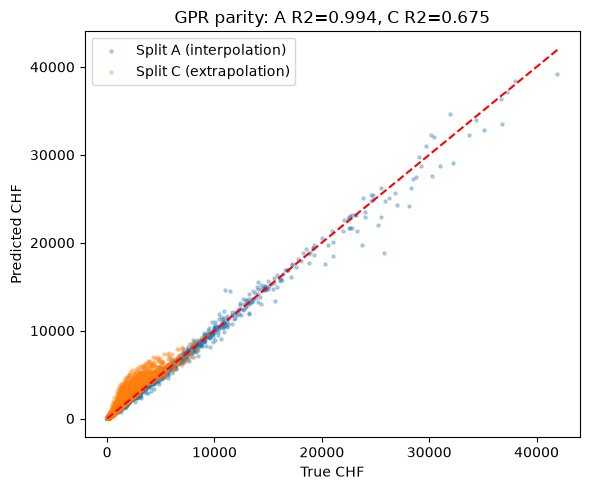

In [4]:

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(yteA, predA, s=5, alpha=0.3, label="Split A (interpolation)")
ax.scatter(yteC, predC, s=5, alpha=0.3, label="Split C (extrapolation)", color="tab:orange")
lims = [0, max(yteA.max(), yteC.max())]
ax.plot(lims, lims, "r--")
ax.set_xlabel("True CHF"); ax.set_ylabel("Predicted CHF")
ax.set_title(f"GPR parity: A R2={r2(yteA,predA):.3f}, C R2={r2(yteC,predC):.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("../results/model_tests_gpr.png", dpi=100)
plt.show()
